<a href="https://colab.research.google.com/github/sierramendoza543/sierra-gating-project/blob/main/edits_syntheticdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#testedit

seed = 42
np.random.seed(seed)

print("Imported numpy, pandas, scipy.stats, matplotlib, seaborn")
print("Random seed set to", seed)

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42


Step 2

In [2]:
# Step 2: harder simulation parameters
#
n_patients_group1 = 10
n_patients_group2 = 10
cells_per_patient = 50
n_genes_total = 1000
n_signal_genes = 100

fold_change = 3
mu_background = 2
sigma2 = 0.20
dispersion = 15.0

size_factor_mean = 2000
size_factor_sd = 300

# --- correlated gene module parameters ---
# Split the 100 signal genes into equal-size modules. All but the last
# module are "disease modules" (their mean expression differs by group,
# same as before). The last module is a "distractor": genes inside it are
# just as correlated with each other as a disease module, but its mean does
# NOT differ between groups — a negative control to check that L1 (and later
# the group-aware method) isn't fooled into selecting a module just because
# it's correlated.
n_modules = 4
n_distractor_modules = 1
genes_per_module = n_signal_genes // n_modules
within_module_correlation = 0.6  # target Pearson rho between genes in the same module

print("Simulation parameters defined")
print("Group 1 patients:", n_patients_group1)
print("Group 2 patients:", n_patients_group2)
print("Cells per patient:", cells_per_patient)
print("Total genes:", n_genes_total)
print("Signal genes:", n_signal_genes)
print("Fold change:", fold_change)
print("Modules:", n_modules, "x", genes_per_module, "genes (", n_distractor_modules, "distractor )")
print("Within-module target correlation:", within_module_correlation)

Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3
Modules: 4 x 25 genes ( 1 distractor )
Within-module target correlation: 0.6


Step 3

In [3]:
# Step 3: create patient metadata

patient_ids = [f"P{i+1}" for i in range(n_patients_group1 + n_patients_group2)]
groups = (
    ["Group1"] * n_patients_group1 +
    ["Group2"] * n_patients_group2
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "group": groups
})

patients_df

,patient_id,group
0,P1,Group1
1,P2,Group1
2,P3,Group1
3,P4,Group1
4,P5,Group1
5,P6,Group1
6,P7,Group1
7,P8,Group1
8,P9,Group1
9,P10,Group1


Step 4

In [4]:
# Step 4: create cell metadata with size factors

cell_rows = []

for _, row in patients_df.iterrows():
    patient_id = row["patient_id"]
    group = row["group"]

    size_factors = np.random.normal(loc=size_factor_mean, scale=size_factor_sd, size=cells_per_patient)
    size_factors = np.clip(size_factors, a_min=1, a_max=None)

    for cell_idx in range(cells_per_patient):
        cell_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": f"{patient_id}_C{cell_idx+1}",
            "size_factor": size_factors[cell_idx]
        })

cells_df = pd.DataFrame(cell_rows)

cells_df.head()

,patient_id,group,cell_id,size_factor
0,P1,Group1,P1_C1,2149.014246
1,P1,Group1,P1_C2,1958.520710
2,P1,Group1,P1_C3,2194.306561
3,P1,Group1,P1_C4,2456.908957
4,P1,Group1,P1_C5,1929.753988


Step 5

In [5]:
# Step 5: label genes and assign correlated gene modules

gene_ids = [f"G{i+1}" for i in range(n_genes_total)]

signal_gene_ids = gene_ids[:n_signal_genes]
background_gene_ids = gene_ids[n_signal_genes:]

module_names = [f"M{i+1}" for i in range(n_modules)]
disease_modules = module_names[: n_modules - n_distractor_modules]
distractor_module_names = module_names[n_modules - n_distractor_modules :]

gene_module = {}
for m_idx, module in enumerate(module_names):
    start = m_idx * genes_per_module
    end = start + genes_per_module
    for gene_id in signal_gene_ids[start:end]:
        gene_module[gene_id] = module

genes_df = pd.DataFrame({
    "gene_id": gene_ids,
    "gene_type": ["signal"] * n_signal_genes + ["background"] * (n_genes_total - n_signal_genes)
})
genes_df["module_id"] = genes_df["gene_id"].map(gene_module).fillna("none")
genes_df["is_disease_module"] = genes_df["module_id"].isin(disease_modules)

print("Disease modules (mean differs by group):", disease_modules)
print("Distractor modules (correlated, but NOT group-differential):", distractor_module_names)
genes_df.head(10)

Disease modules (mean differs by group): ['M1', 'M2', 'M3']
Distractor modules (correlated, but NOT group-differential): ['M4']


,gene_id,gene_type,module_id,is_disease_module
0,G1,signal,M1,True
1,G2,signal,M1,True
2,G3,signal,M1,True
3,G4,signal,M1,True
4,G5,signal,M1,True
5,G6,signal,M1,True
6,G7,signal,M1,True
7,G8,signal,M1,True
8,G9,signal,M1,True
9,G10,signal,M1,True


Step 6

In [6]:
# Step 6: patient random effects

patient_effects = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2),
    size=len(patients_df)
)

patients_df["gamma_i"] = patient_effects

patients_df

,patient_id,group,gamma_i
0,P1,Group1,0.625811
1,P2,Group1,0.413509
2,P3,Group1,0.026668
3,P4,Group1,-0.289319
4,P5,Group1,0.312255
5,P6,Group1,0.175972
6,P7,Group1,0.400343
7,P8,Group1,0.284057
8,P9,Group1,0.469374
9,P10,Group1,-0.239364


Step 7

In [7]:
# Step 7: define group-specific means
#
# Disease-module genes: mean shifts with group (fold_change applied in Group1)
# Distractor-module genes: same mean in both groups (correlated, not diagnostic)
# Background genes: unchanged, independent, same mean in both groups

mu_group1_signal = mu_background * fold_change
mu_group2_signal = mu_background

mu_group1_background = mu_background
mu_group2_background = mu_background

print("mu_group1_signal (disease modules, Group1) =", mu_group1_signal)
print("mu_group2_signal (disease modules, Group2) =", mu_group2_signal)
print("mu_group1_background (distractor module + background, Group1) =", mu_group1_background)
print("mu_group2_background (distractor module + background, Group2) =", mu_group2_background)

mu_group1_signal (disease modules, Group1) = 6
mu_group2_signal (disease modules, Group2) = 2
mu_group1_background (distractor module + background, Group1) = 2
mu_group2_background (distractor module + background, Group2) = 2


Step 8

In [8]:
# Step 8: simulate gene expression counts (module-aware Gaussian copula NB sampling)
#
# Genes within the same module are sampled with a Gaussian copula: draw a
# vector of correlated standard-normal latents per (module, cell) using a
# compound-symmetric correlation matrix (within_module_correlation on the
# off-diagonals), map each latent to a uniform via the standard normal CDF,
# then invert each gene's own NB CDF at that uniform (nbinom.ppf). This keeps
# every gene's marginal NB distribution exactly as parameterized (same mean/
# dispersion as before) while inducing real pairwise correlation among genes
# in the same module. Background genes are sampled independently, unchanged.
#
# A separate Generator is used for the copula draws so the existing global
# np.random stream (patients_df, cells_df, background genes) is undisturbed.

from scipy.stats import nbinom, norm

rng = np.random.default_rng(seed)

# One compound-symmetric correlation matrix / Cholesky factor covers every
# module (same size, same target rho), so compute it once.
corr_matrix = (
    np.eye(genes_per_module) * (1 - within_module_correlation)
    + within_module_correlation
)
chol_factor = np.linalg.cholesky(corr_matrix)

module_gene_lists = {
    module: genes_df.loc[genes_df["module_id"] == module, "gene_id"].tolist()
    for module in module_names
}

count_rows = []

for _, cell in cells_df.iterrows():
    patient_id = cell["patient_id"]
    group = cell["group"]
    cell_id = cell["cell_id"]
    size_factor = cell["size_factor"]
    gamma_i = patients_df.loc[patients_df["patient_id"] == patient_id, "gamma_i"].values[0]

    disease_mu_base = mu_group1_signal if group == "Group1" else mu_group2_signal

    for module in module_names:
        gene_list = module_gene_lists[module]

        if module in disease_modules:
            mu_gene = size_factor * (disease_mu_base + gamma_i)
        else:
            mu_gene = size_factor * mu_background

        var = mu_gene + (mu_gene ** 2) / dispersion
        p = mu_gene / var
        n = mu_gene * p / (1 - p)

        z = chol_factor @ rng.standard_normal(genes_per_module)
        u = np.clip(norm.cdf(z), 1e-6, 1 - 1e-6)
        exprs = nbinom.ppf(u, n, p).astype(int)

        for gene_id, expr in zip(gene_list, exprs):
            count_rows.append({
                "patient_id": patient_id,
                "group": group,
                "cell_id": cell_id,
                "gene_id": gene_id,
                "gene_type": "signal",
                "module_id": module,
                "expression": expr
            })

    for gene_id in background_gene_ids:
        mu = size_factor * mu_background
        var = mu + (mu ** 2) / dispersion
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "background",
            "module_id": "none",
            "expression": expr
        })

counts_df = pd.DataFrame(count_rows)
counts_df.head()

,patient_id,group,cell_id,gene_id,gene_type,module_id,expression
0,P1,Group1,P1_C1,G1,signal,M1,15059
1,P1,Group1,P1_C1,G2,signal,M1,11698
2,P1,Group1,P1_C1,G3,signal,M1,15534
3,P1,Group1,P1_C1,G4,signal,M1,16597
4,P1,Group1,P1_C1,G5,signal,M1,10029


Step 9

In [9]:
# Step 9: reshape to gene x cell matrix

expression_matrix = counts_df.pivot_table(
    index="gene_id",
    columns="cell_id",
    values="expression",
    aggfunc="sum"
)
#new los min Loss contrastive (from Jessica's paper) + lambda sum of stochastic gate values
expression_matrix

cell_id,P10_C1,P10_C10,P10_C11,P10_C12,P10_C13,P10_C14,P10_C15,P10_C16,P10_C17,P10_C18,...,P9_C46,P9_C47,P9_C48,P9_C49,P9_C5,P9_C50,P9_C6,P9_C7,P9_C8,P9_C9
gene_id,,,,,,,,,,,,,,,,,,,,,
G1,12779,13556,17119,13672,13264,16712,5239,10764,9792,10162,...,14218,18468,13900,9160,12461,9170,11780,11383,11107,12538
G10,11966,11523,17238,11534,13805,14171,12846,11788,11107,9137,...,16708,14887,10589,8224,10684,8852,13222,11542,10022,14717
G100,4239,1927,5789,2658,4726,4532,3073,3593,3721,4586,...,4075,3906,3069,5109,4466,4396,3825,2755,4224,4314
G1000,5781,2604,4081,5213,3389,3916,3413,4930,3177,6862,...,4054,4530,2972,3366,4352,3270,5112,2899,3786,4380
G101,3145,2672,5404,4494,4480,3168,2437,5097,2329,5686,...,6876,4501,3886,4604,4290,2738,3613,3129,4710,2796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G995,2820,2695,4914,5337,3603,2717,4150,2852,5387,2773,...,6789,3773,3493,2065,4285,3601,3409,3275,3565,3998
G996,4201,3650,5272,5394,2273,4507,3994,4042,3586,4140,...,3717,3328,4717,5764,3004,3416,4382,4763,5049,2927
G997,3452,3825,5663,2769,4013,4228,5732,3460,3412,5700,...,4692,6206,1789,2796,4662,3485,3775,5664,4029,5734


Step 10

In [10]:
# Step 10: basic validation summaries

summary_by_gene = counts_df.groupby(["gene_id", "gene_type"])["expression"].agg(
    ["mean", "median", "std", "min", "max"]
).reset_index()

summary_by_gene.head(10)

,gene_id,gene_type,mean,median,std,min,max
0,G1,signal,8347.855,7170.5,4936.730946,1499,29085
1,G10,signal,8418.393,7333.0,4927.567699,1410,25300
2,G100,signal,3967.426,3869.5,1224.210717,1297,10965
3,G1000,background,4018.613,3890.0,1199.474532,1400,8610
4,G101,background,4021.840,3883.5,1197.525056,1167,7796
5,G102,background,3988.742,3885.0,1195.189973,1060,8750
6,G103,background,3986.686,3797.0,1223.236540,806,10623
7,G104,background,4016.262,3876.0,1216.416261,1311,10582
8,G105,background,4008.454,3858.5,1226.321674,1316,9194
9,G106,background,4026.249,3864.0,1198.305924,1343,9554


Step 11

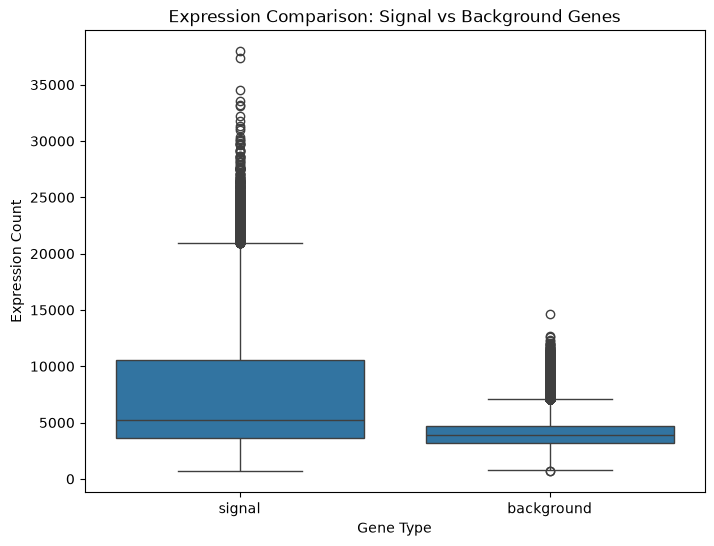

In [11]:
# Step 11: box plot for signal vs background gene expression

plot_df = counts_df.copy()

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="gene_type", y="expression")
plt.title("Expression Comparison: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Expression Count")
plt.show()

Step 11b: validate the induced module correlation

In [12]:
# Step 11b: check realized within-module correlation
#
# Raw counts are contaminated by a technical correlation floor: size_factor
# multiplies every gene's mean within a cell, so ALL genes look correlated
# with each other regardless of module structure. To see the correlation the
# copula actually added, normalize expression by size_factor first (CPM-style)
# before computing pairwise correlations. Restricting to Group1 cells also
# avoids the trivial correlation induced by the group mean difference itself.

norm_counts_df = counts_df.merge(cells_df[["cell_id", "size_factor"]], on="cell_id")
norm_counts_df["norm_expression"] = norm_counts_df["expression"] / norm_counts_df["size_factor"]

g1_cells = cells_df.loc[cells_df["group"] == "Group1", "cell_id"]
norm_mat_g1 = norm_counts_df[norm_counts_df["cell_id"].isin(g1_cells)].pivot_table(
    index="gene_id", columns="cell_id", values="norm_expression"
)

def avg_offdiag_corr(gene_list):
    sub = norm_mat_g1.loc[gene_list]
    c = sub.T.corr().values
    mask = ~np.eye(len(gene_list), dtype=bool)
    return c[mask].mean()

module_corr_results = {}
print("Avg pairwise correlation (normalized expression, Group1 cells only)")
print("-" * 65)
for module in module_names:
    kind = "disease" if module in disease_modules else "distractor"
    genes_in_module = module_gene_lists[module]
    corr_val = avg_offdiag_corr(genes_in_module)
    module_corr_results[module] = corr_val
    print(f"{module} ({kind:10s}): {corr_val:.3f}")

bg_sample = list(np.random.choice(background_gene_ids, genes_per_module, replace=False))
background_corr = avg_offdiag_corr(bg_sample)
print(f"{'background':13s}: {background_corr:.3f}")

Avg pairwise correlation (normalized expression, Group1 cells only)
-----------------------------------------------------------------
M1 (disease   ): 0.594
M2 (disease   ): 0.620
M3 (disease   ): 0.586
M4 (distractor): 0.581
background   : 0.001


Step 11c: dataset overview

In [13]:
# Step 11c: dataset overview

overview = pd.DataFrame({
    "quantity": [
        "Patients (total)", "Patients per group (G1 / G2)", "Cells per patient", "Cells (total)",
        "Genes (total)", "Signal genes (in modules)", "Background genes",
        "Disease modules", "Distractor modules", "Genes per module",
        "Target within-module correlation", "Fold change (disease modules)",
        "NB dispersion", "Patient-effect variance (sigma2)"
    ],
    "value": [
        len(patients_df), f"{n_patients_group1} / {n_patients_group2}", cells_per_patient, len(cells_df),
        n_genes_total, n_signal_genes, n_genes_total - n_signal_genes,
        len(disease_modules), len(distractor_module_names), genes_per_module,
        within_module_correlation, fold_change,
        dispersion, sigma2
    ]
})
overview

,quantity,value
0,Patients (total),20
1,Patients per group (G1 / G2),10 / 10
2,Cells per patient,50
3,Cells (total),1000
4,Genes (total),1000
5,Signal genes (in modules),100
6,Background genes,900
7,Disease modules,3
8,Distractor modules,1
9,Genes per module,25


Step 11d: technical and patient-effect distributions (QC)

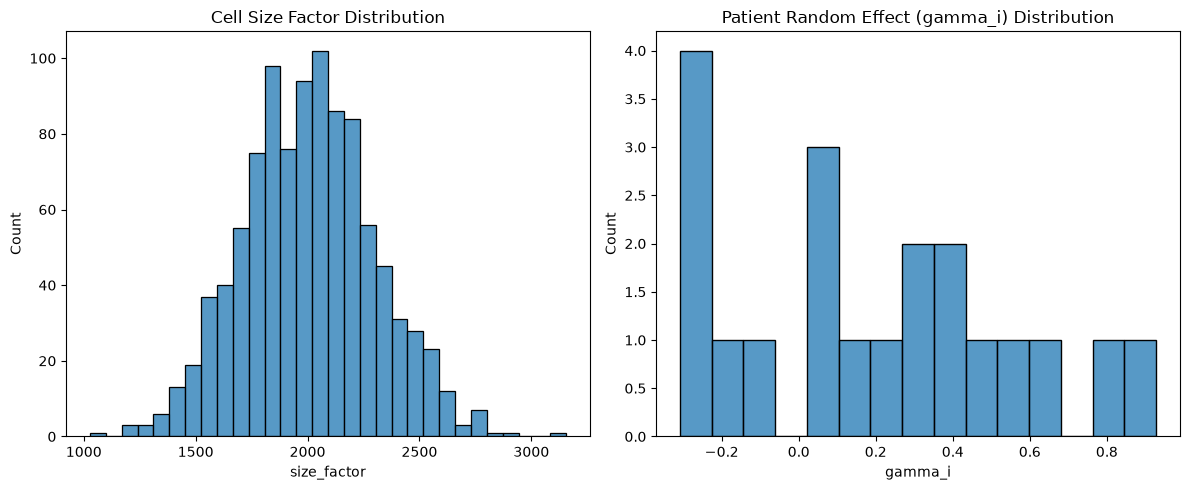

,mean,std,min,max
group,,,,
Group1,0.217930,0.301689,-0.289319,0.625811
Group2,0.170096,0.449775,-0.308214,0.928085


In [14]:
# Step 11d: technical and patient-effect distributions (QC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(cells_df["size_factor"], bins=30, ax=axes[0])
axes[0].set_title("Cell Size Factor Distribution")
axes[0].set_xlabel("size_factor")

sns.histplot(patients_df["gamma_i"], bins=15, ax=axes[1])
axes[1].set_title("Patient Random Effect (gamma_i) Distribution")
axes[1].set_xlabel("gamma_i")

plt.tight_layout()
plt.show()

patients_df.groupby("group")["gamma_i"].agg(["mean", "std", "min", "max"])

Step 11e: expression distribution by gene type (log scale)

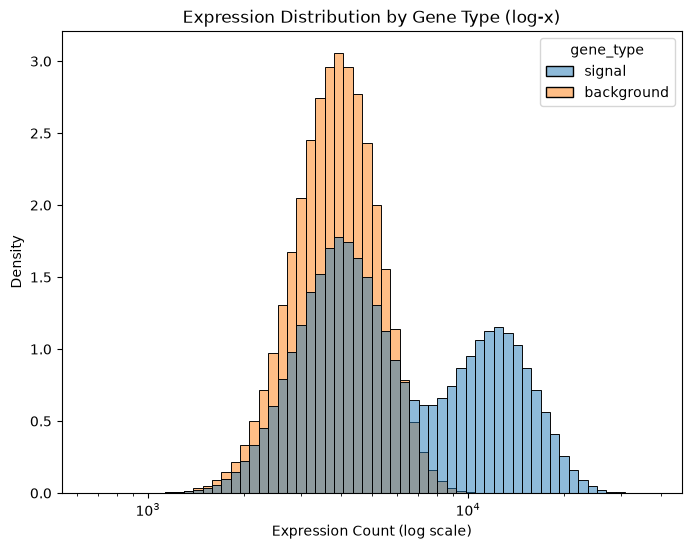

In [15]:
# Step 11e: expression distribution by gene type (log scale)

plt.figure(figsize=(8, 6))
sns.histplot(
    data=counts_df, x="expression", hue="gene_type",
    bins=60, log_scale=(True, False), stat="density", common_norm=False, alpha=0.5
)
plt.title("Expression Distribution by Gene Type (log-x)")
plt.xlabel("Expression Count (log scale)")
plt.show()

Step 11f: per-module expression by group (does the fold-change show up per module?)

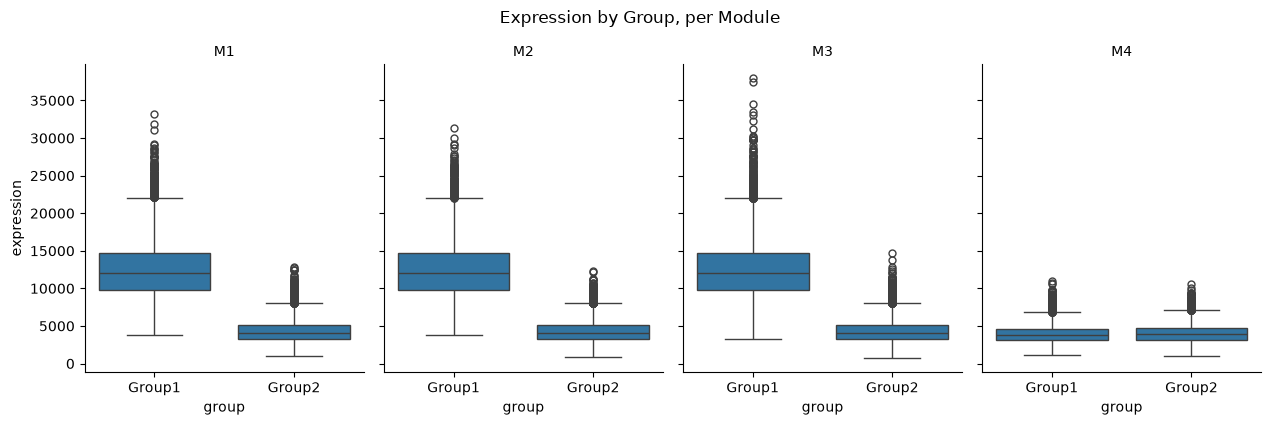

In [16]:
# Step 11f: per-module expression by group
#
# Disease modules (M1-M3) should show a visible shift between Group1 and
# Group2; the distractor module (M4) should not, even though it is just as
# internally correlated.

module_counts = counts_df[counts_df["module_id"] != "none"]

g = sns.catplot(
    data=module_counts, x="group", y="expression", col="module_id",
    kind="box", col_order=module_names, height=4, aspect=0.8
)
g.set_titles("{col_name}")
g.fig.suptitle("Expression by Group, per Module", y=1.05)
plt.show()

Step 11g: correlation heatmaps — disease module vs distractor vs background

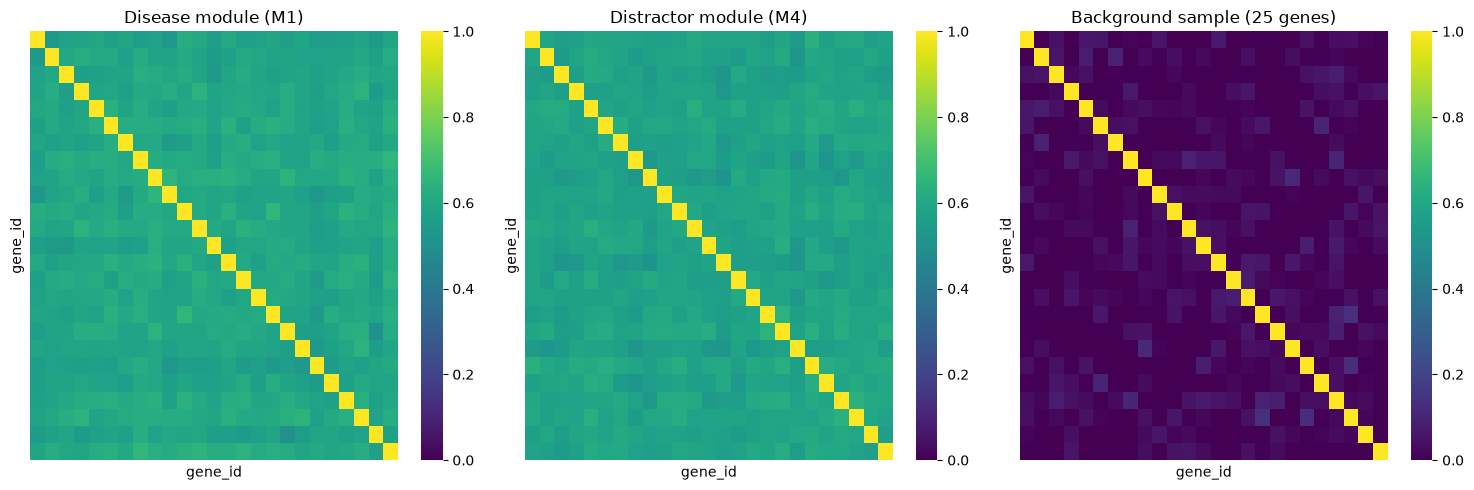

In [17]:
# Step 11g: correlation heatmaps -- disease module vs distractor vs background
#
# Visual counterpart to the numbers above: a disease module and the
# distractor module should both show a solid block of correlation, while a
# random sample of background genes should look like noise.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

heatmap_specs = [
    (module_gene_lists[disease_modules[0]], f"Disease module ({disease_modules[0]})"),
    (module_gene_lists[distractor_module_names[0]], f"Distractor module ({distractor_module_names[0]})"),
    (bg_sample, "Background sample (25 genes)")
]

for ax, (gene_list, title) in zip(axes, heatmap_specs):
    corr = norm_mat_g1.loc[gene_list].T.corr()
    sns.heatmap(corr, ax=ax, vmin=0, vmax=1, cmap="viridis", cbar=True, xticklabels=False, yticklabels=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

Step 11h: PCA of cells using only module genes

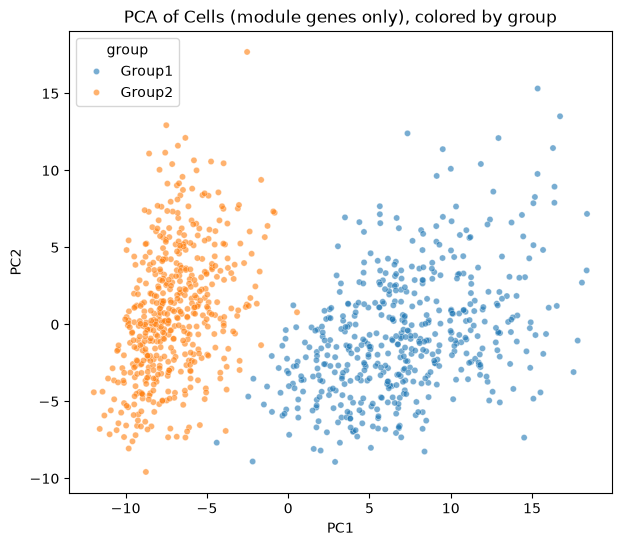

In [18]:
# Step 11h: PCA of cells using only module genes (disease + distractor)
#
# If the disease modules carry real group signal, cells should separate by
# group along the leading principal components even before any classifier
# is trained on them.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

module_gene_ids = [g for genes in module_gene_lists.values() for g in genes]
signal_matrix = counts_df[counts_df["gene_id"].isin(module_gene_ids)].pivot_table(
    index="cell_id", columns="gene_id", values="expression", fill_value=0
)

cell_group_lookup = cells_df.set_index("cell_id")["group"].loc[signal_matrix.index]

scaled = StandardScaler().fit_transform(signal_matrix.values)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaled)

pca_df = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1], "group": cell_group_lookup.values})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group", alpha=0.6, s=20)
plt.title("PCA of Cells (module genes only), colored by group")
plt.show()

Step 12

# L1 Gating Test

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GroupShuffleSplit

# scikit-learn >=1.8 emits a FutureWarning about the penalty= param being
# deprecated in favor of l1_ratio=; harmless here (we're pinned to
# penalty="l1"/solver="saga"), suppressed so it doesn't clutter the report.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [20]:
# Build cell-level matrix
X_df = counts_df.pivot_table(
    index="cell_id",
    columns="gene_id",
    values="expression",
    aggfunc="sum",
    fill_value=0
)

cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values

gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]

In [21]:
# Split and train L1 model
# X_train, X_test, y_train, y_test = train_test_split(
#     X_df.values, y, test_size=0.2, random_state=42, stratify=y
# )

groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))

X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

#cross validation for lambda tuning, define loss function
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.0054,  #C=1/Lambda. Low C- strong regularization, high C- weak regularization
    # tuned via sweep to land test accuracy in the ~75-85% target zone with the
    # module design (see CLAUDE.md parameter tuning notes)
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.93375
Test accuracy: 0.805


In [22]:
# Extract gene scores
coef = model.coef_[0]

feature_scores = pd.DataFrame({
    "gene_id": X_df.columns,
    "gene_type": gene_types.values,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

feature_scores.head()

,gene_id,gene_type,coef,abs_coef
0,G1,signal,-0.126492,0.126492
1,G10,signal,0.000000,0.000000
2,G100,signal,0.000000,0.000000
3,G1000,background,0.000000,0.000000
4,G101,background,0.000000,0.000000


Step 12b: does L1 recover whole modules, or just 1-2 representative genes?

module_id       kind  genes_in_module  genes_recovered  recovery_rate
       M1    disease               25                6           0.24
       M2    disease               25                3           0.12
       M3    disease               25                4           0.16
       M4 distractor               25                0           0.00


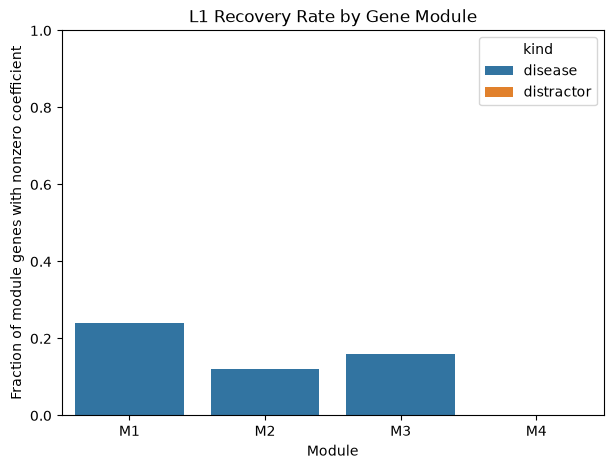

In [23]:
# Step 12b: per-module recovery rate
#
# Recovery rate = (# genes in a module with a nonzero L1 coefficient) / (module size).
# This is the core empirical test: if L1 treats genes independently, it should
# grab only a handful of "representative" genes per disease module even though
# the whole module carries signal. The distractor module is a negative control:
# it's just as internally correlated as a disease module, but should get ~0
# recovery since it carries no group-discriminating signal.

feature_scores = feature_scores.merge(
    genes_df[["gene_id", "module_id", "is_disease_module"]], on="gene_id"
)

recovery_rows = []
for module in module_names:
    sub = feature_scores[feature_scores["module_id"] == module]
    n_nonzero = (sub["coef"] != 0).sum()
    recovery_rows.append({
        "module_id": module,
        "kind": "disease" if module in disease_modules else "distractor",
        "genes_in_module": len(sub),
        "genes_recovered": n_nonzero,
        "recovery_rate": n_nonzero / len(sub)
    })

recovery_df = pd.DataFrame(recovery_rows)
print(recovery_df.to_string(index=False))

plt.figure(figsize=(7, 5))
sns.barplot(data=recovery_df, x="module_id", y="recovery_rate", hue="kind")
plt.title("L1 Recovery Rate by Gene Module")
plt.xlabel("Module")
plt.ylabel("Fraction of module genes with nonzero coefficient")
plt.ylim(0, 1)
plt.show()

Step 12c: L1 coefficient magnitude by module

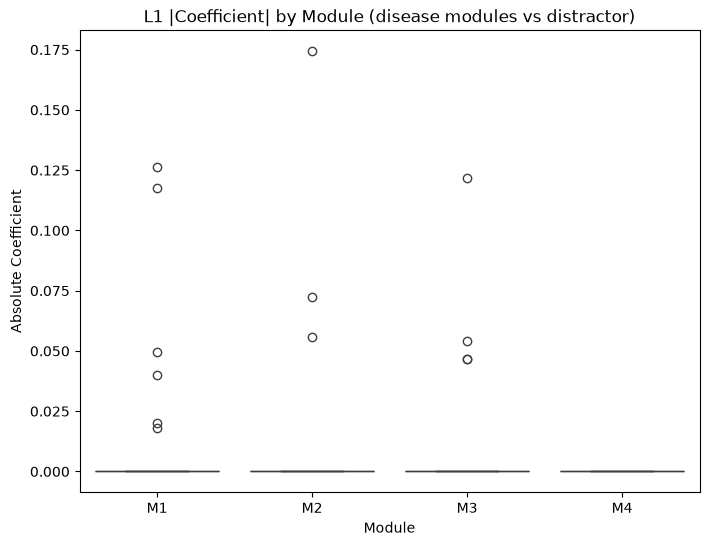

In [24]:
# Step 12c: L1 coefficient magnitude by module

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=feature_scores[feature_scores["module_id"] != "none"],
    x="module_id", y="abs_coef", order=module_names
)
plt.title("L1 |Coefficient| by Module (disease modules vs distractor)")
plt.xlabel("Module")
plt.ylabel("Absolute Coefficient")
plt.show()

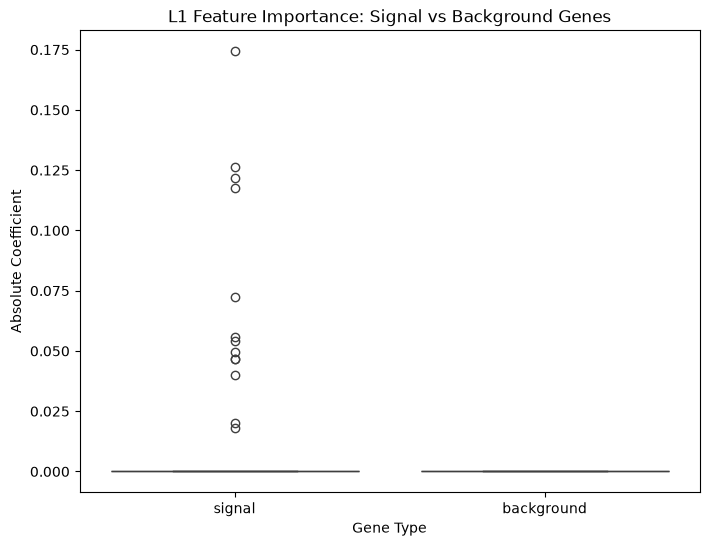

In [25]:
# Compare signal vs. background
plt.figure(figsize=(8, 6))
sns.boxplot(data=feature_scores, x="gene_type", y="abs_coef")
plt.title("L1 Feature Importance: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Absolute Coefficient")
plt.show()

In [26]:
# Long format (one row per cell-gene pair) — good for records/reproducibility
#counts_df.to_csv("counts_long.csv", index=False)

# Wide format (genes as rows, cells as columns) — good for feeding into a model
#expression_matrix.to_csv("expression_matrix.csv")

# Gene answer key (which genes are signal vs background)
#genes_df.to_csv("genes_labels.csv", index=False)

# Patient metadata (group, gamma_i)
#patients_df.to_csv("patients.csv", index=False)

Step 13: summary report

In [27]:
# Step 13: summary report

summary_report = pd.DataFrame({
    "metric": [
        "Test accuracy", "Train accuracy", "L1 regularization C",
        "Total nonzero coefficients", "Background genes w/ nonzero coef",
        "Disease module avg recovery rate", "Distractor module recovery rate",
        "Target within-module correlation",
        "Realized correlation - disease modules (avg)",
        "Realized correlation - distractor module",
        "Realized correlation - background genes"
    ],
    "value": [
        round(test_acc, 4),
        round(train_acc, 4),
        model.C,
        int((feature_scores["coef"] != 0).sum()),
        int((feature_scores.loc[feature_scores["gene_type"] == "background", "coef"] != 0).sum()),
        round(recovery_df.loc[recovery_df["kind"] == "disease", "recovery_rate"].mean(), 4),
        round(recovery_df.loc[recovery_df["kind"] == "distractor", "recovery_rate"].mean(), 4),
        within_module_correlation,
        round(np.mean([module_corr_results[m] for m in disease_modules]), 4),
        round(module_corr_results[distractor_module_names[0]], 4),
        round(background_corr, 4)
    ]
})
summary_report

,metric,value
0,Test accuracy,0.8050
1,Train accuracy,0.9337
2,L1 regularization C,0.0054
3,Total nonzero coefficients,13.0000
4,Background genes w/ nonzero coef,0.0000
5,Disease module avg recovery rate,0.1733
6,Distractor module recovery rate,0.0000
7,Target within-module correlation,0.6000
8,Realized correlation - disease modules (avg),0.6001
9,Realized correlation - distractor module,0.5805
